# High-Water 🏔️
### "Buy stocks near their 52-week high" — a distinct edge, or just momentum?

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![A distinct anomaly?: Busted](https://img.shields.io/badge/A_distinct_anomaly%3F-Busted-8b949e?style=flat-square)

There's a famous idea that stocks trading near their one-year high keep climbing — an *anchoring* story said to be different from plain momentum. We test both halves on large-cap stocks: no premium showed up (the long-short lost on our panel — though the panel itself, made of today's survivors, pushes the sign that way), and it turns out to be 0.82 correlated with ordinary 12-2 momentum — the same factor with a behavioural label. That correlation, not the loss, is the finding that doesn't depend on the panel.

> 📓 **Plain-language layer.** The correlation and the t-stats are in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** Every chart is generated by the code beside it.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))  # repo root (quantlab/)
sys.path.insert(0, os.path.abspath(".."))        # study package (high_water/)
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5); plt.rcParams["axes.grid"] = True
import numpy as np, pandas as pd
from high_water import data, strategy as st
# Opt-in, stated: current S&P 500 members + a >=20y-history filter = a survivor panel. Here the
# bias hits the SIGN: the short leg (fallen names) is guaranteed survivors, so the negative hedge
# is partly manufactured. The momentum correlation is the bias-robust number.
ret = data.fetch_panel(allow_survivorship_bias=True)   # cache-first; built by examples/verify.py --fetch
hi = st.cross_section_hedge(ret, st.nearness(ret))
mo = st.cross_section_hedge(ret, st.momentum(ret))     # standard 12-2 momentum (skips the last month)


## The answer first 🎯

| The claim | The data (1996–2026, large caps) |
|---|---|
| "Near-high stocks out-earn" | No premium: the long-short showed **−8.4%/yr** (Sharpe −0.40) — a loss on *this survivor panel*, whose short leg (fallen names that we know rebounded into today's index) partly manufactures the sign. |
| "It's distinct from momentum" | It's **0.82 correlated** with the standard 12-2 momentum hedge — and that number doesn't care about the panel's bias. |
| "A free anchoring edge" | Nothing positive gross, so costs only deepen the hole. |

## 1 · The claim

George & Hwang (2004): a stock's **nearness to its 52-week high** (price ÷ one-year high) predicts its return — investors anchor on the high and underreact — and this beats, and is *separate from*, Jegadeesh-Titman momentum.

## 2 · So what?

If it's a distinct, durable edge, it's another factor for the toolbox. If it's momentum relabelled — and momentum that didn't even pay on large caps — then it's a story dressed as a discovery.

## 3 · How would we even know?

Build the nearness long-short, measure its return and t-stat, then **correlate it with a standard 12-2 momentum long-short** (trailing year, skipping the most recent month). High correlation means same factor; no positive return means no premium to begin with. One warning before reading any level: our panel is **today's index members with 20+ years of history** — survivors — and here that bias has teeth, because the short side holds beaten-down names we *know* came back. The correlation between the two hedges is the measurement that survives this; the minus sign is not.

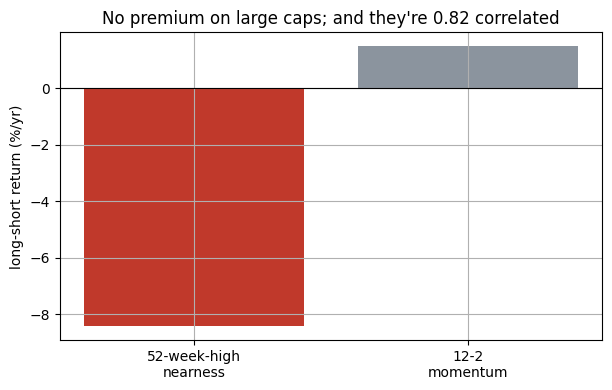

In [2]:
h,m=st.stats(hi),st.stats(mo)
fig,ax=plt.subplots(figsize=(7,4))
ax.bar(['52-week-high\nnearness','12-2\nmomentum'],[h['mean_ann']*100,m['mean_ann']*100],color=['#c0392b','#8b949e'])
ax.set_ylabel('long-short return (%/yr)'); ax.axhline(0,color='k',lw=.8)
ax.set_title(f"No premium on large caps; and they're {st.signal_overlap(ret):.2f} correlated"); plt.show()

## 4 · The teardown

The two hedges move together — because they *are* the same bet. The nearness book got crushed in the 2000 and 2008 rebounds — exactly when the survivor effect bites hardest, since the fallen names in our short leg are, by construction, the ones that came back.

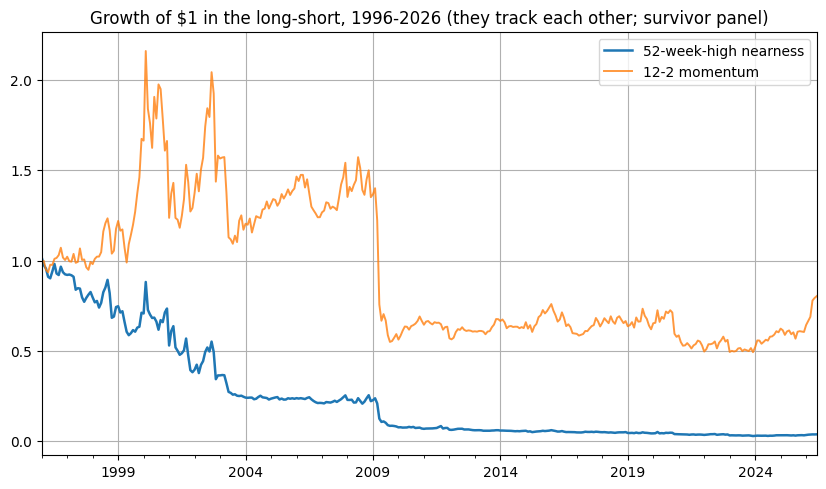

correlation of the two hedges: +0.82


In [3]:
eqH=(1+hi).cumprod(); eqM=(1+mo).cumprod()
ax=eqH.plot(label='52-week-high nearness',lw=1.8); eqM.plot(ax=ax,label='12-2 momentum',lw=1.4,alpha=.8)
ax.set_title('Growth of $1 in the long-short, 1996-2026 (they track each other; survivor panel)'); ax.legend(); plt.show()
print(f"correlation of the two hedges: {st.signal_overlap(ret):+.2f}")

**Read it plainly.** Two lines tracking each other, neither going anywhere good. The 52-week-high signal isn't a new edge — it's momentum. And the 'it lost money' part should be read with the panel in mind: a universe of guaranteed survivors makes shorting fallen names look worse than it really was. What the panel *can't* fake is that there's no positive premium and no separate factor.

## 5 · The verdict

**Signal: None** — no positive premium anywhere; the measured loss is partly the survivor panel's doing, but a manufactured-negative is still not a positive. **Tradability: Mirage** — nothing gross to keep, and one-way turnover digs. **A distinct anomaly?: Busted** — 0.82 correlated with standard 12-2 momentum, and that's the bias-insensitive number.

## 6 · Could you actually trade it?

There's nothing to trade: no positive gross hedge, and to the extent the signal captures anything, it's the momentum factor you could get more cleanly (and which also struggled here — see [Study 24 Stampede](../../24-stampede/)).

## 7 · Going further 🚪

The quants notebook shows the 0.82 correlation, the survivor-sign caveat and the decay. This closes the second five-study bench (46–50). The rebound mechanics behind the negative sign tie to [Study 33 Slingshot](../../33-slingshot/) — reversal on the S&P cross-section.